<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"


### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Test Environment


In [ ]:
# Keep appending the code generated to this cell, or add more cells below this to execute in parts
# This script reads a CSV file from the given path into a Pandas DataFrame. The first row is treated as headers by default (header=0).

import pandas as pd

# Path to the CSV file
file_path = "dataset.csv"

# Read the CSV into a DataFrame. By default, header=0, so the first row is treated as column names.
df = pd.read_csv(file_path)

# Optional: display basic information about the loaded DataFrame
print(df.head())
print('Rows:', len(df), 'Columns:', len(df.columns))


     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  
Rows: 17966 Columns: 9


In [19]:
import numpy as np
cols_with_missing = df.columns[df.isnull().any()].tolist() 
print(cols_with_missing)

['tax']


In [20]:
numeric_cols_with_missing = df[cols_with_missing].select_dtypes(include=[np.number]).columns.tolist() 
df[numeric_cols_with_missing] = df[numeric_cols_with_missing].fillna(df[numeric_cols_with_missing].mean())

In [21]:
df = df.drop_duplicates()

In [22]:
def top_correlated_features(df: pd.DataFrame, target: str, top_n: int = 5, method: str = 'pearson') -> pd.DataFrame:
    """
    Identify top_n numeric features most correlated with the target column.

    Parameters:
    - df: DataFrame containing the data
    - target: name of the target column
    - top_n: number of top features to return (default 5)
    - method: correlation method ('pearson', 'spearman', etc.)

    Returns:
    - DataFrame with columns: 'feature' and 'correlation' (absolute correlation, sorted desc)
    """
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found in DataFrame.")

    # Numeric feature columns excluding the target
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target in numeric_cols:
        numeric_cols.remove(target)

    if not numeric_cols:
        return pd.DataFrame(columns=['feature', 'correlation'])

    # Convert target to numeric (coerce errors to NaN)
    y = pd.to_numeric(df[target], errors='coerce')

    # Compute correlations between each numeric feature and the target
    corr = df[numeric_cols].corrwith(y, method=method)

    # Drop NaNs, take absolute value for ranking
    corr = corr.dropna()
    corr_abs = corr.abs()

    top = corr_abs.sort_values(ascending=False).head(top_n)

    return pd.DataFrame({'feature': top.index.astype(str), 'correlation': top.values})

# Example usage:
# df = pd.read_csv("path/to/your/data.csv")
top5 = top_correlated_features(df, target='price', top_n=5)
print(top5)

      feature  correlation
0        year     0.635715
1     mileage     0.530483
2  engineSize     0.411451
3         tax     0.405970
4         mpg     0.346263


In [23]:
def count_unique_values(df: pd.DataFrame, column: str, include_nan: bool = False,
                        sort_by: str = 'count', ascending: bool = False) -> pd.DataFrame:
    """
    Count occurrences of each unique value in the specified column.

    Parameters:
      - df: DataFrame
      - column: column name to analyze
      - include_nan: if True, include NaN as a separate category
      - sort_by: 'count' to sort by frequency, 'value' to sort by the actual value
      - ascending: sort order

    Returns:
      A DataFrame with columns [column, 'count'] sorted according to sort_by/ascending.
    """
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    counts = df[column].value_counts(dropna=not include_nan)
    result = counts.reset_index()
    result.columns = [column, 'count']

    if sort_by == 'value':
        result = result.sort_values(column, ascending=ascending)
    else:
        result = result.sort_values('count', ascending=ascending)

    return result

# Example usage:
# df = pd.read_csv("path/to/file.csv")
counts_df = count_unique_values(df, column='fuelType', include_nan=True)
print(counts_df)

   fuelType  count
0    Petrol  12081
1    Diesel   5706
2    Hybrid     22
3  Electric      2
4     Other      1


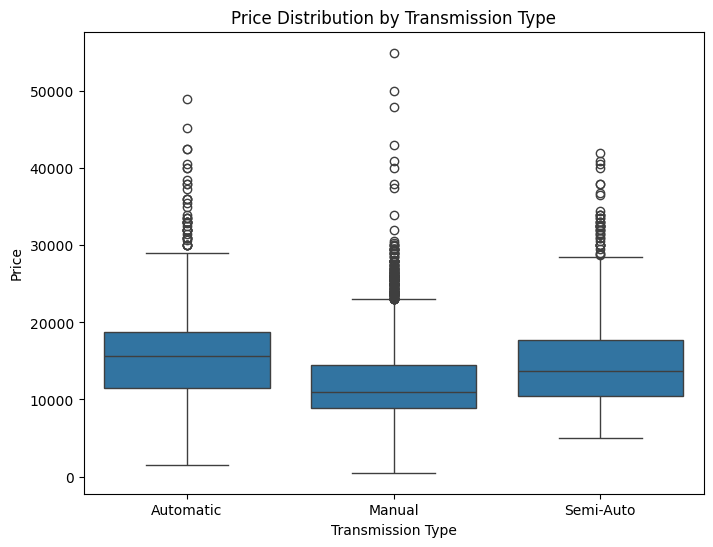

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the box plot
plt.figure(figsize=(8,6))
sns.boxplot(x='transmission', y='price', data=df)

# Labels and title
plt.title('Price Distribution by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Price')

# Show plot
plt.show()


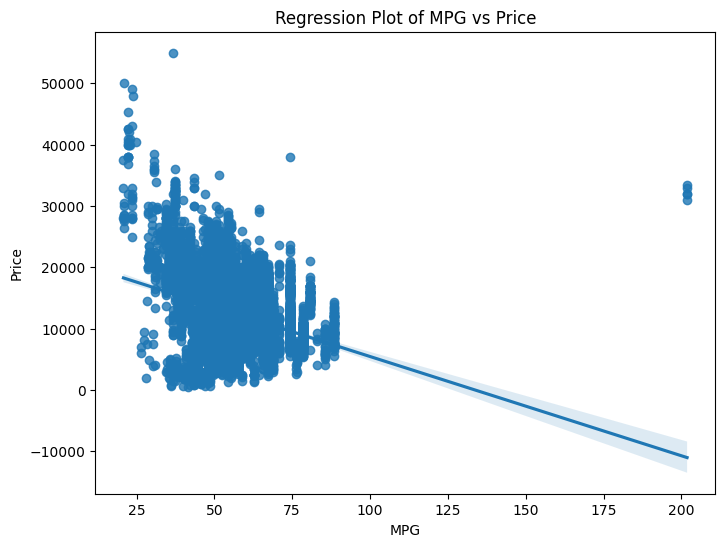

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create regression plot between mpg and price
plt.figure(figsize=(8, 6))
sns.regplot(x='mpg', y='price', data=df)

# Labels and title
plt.title('Regression Plot of MPG vs Price')
plt.xlabel('MPG')
plt.ylabel('Price')

# Show plot
plt.show()

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define feature and target
X = df[['mpg']]
y = df['price']

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict price
y_pred = model.predict(X)

# Calculate R^2 and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

# Print results
print("R^2:", r2)
print("MSE:", mse)

R^2: 0.1198980224962416
MSE: 19741690.809446193


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define features and target
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Predict values
y_pred = model.predict(X)

# Calculate evaluation metrics
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

# Print results
print("R^2:", r2)
print("MSE:", mse)

R^2: 0.7265379654547005
MSE: 6134065.224381731


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define features and target
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])

# Fit the pipeline
pipeline.fit(X, y)

# Predict values
y_pred = pipeline.predict(X)

# Calculate metrics
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

# Print results
print("R^2:", r2)
print("MSE:", mse)

R^2: 0.7666619695239302
MSE: 5234038.06546274


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Define features and target
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and fit Ridge regression model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

# Predict on test data
y_pred_test = ridge_model.predict(X_test)

# Calculate R^2 score
r2 = r2_score(y_test, y_pred_test)

# Print result
print("R^2:", r2)

R^2: 0.6917134446113138


In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Define features and target
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply second order polynomial transformation
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and fit Ridge regression model
ridge_poly_model = Ridge(alpha=0.1)
ridge_poly_model.fit(X_train_poly, y_train)

# Predict on transformed test data
y_pred_test = ridge_poly_model.predict(X_test_poly)

# Calculate R^2 and MSE
r2 = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)

# Print results
print("R^2:", r2)
print("MSE:", mse)

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.17676e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


R^2: 0.6732748888228912
MSE: 7326174.516559619


In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# Define features and target
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply second order polynomial transformation
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Define Ridge model
ridge = Ridge()

# Define parameter grid
parameters = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Perform Grid Search with 4-fold cross-validation
ridge_grid = GridSearchCV(ridge, parameters, cv=4)
ridge_grid.fit(X_train_poly, y_train)

# Best alpha value
best_alpha = ridge_grid.best_params_['alpha']
best_model = ridge_grid.best_estimator_

# Print results
print("Best alpha:", best_alpha)
print("Best cross-validation score:", ridge_grid.best_score_)

# Optional: test set prediction
y_pred = best_model.predict(X_test_poly)
print("Test R^2:", r2_score(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.93807e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.88233e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=3.01744e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.78199e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.93807e-24): res

Best alpha: 0.01
Best cross-validation score: 0.7735031602542886
Test R^2: 0.38273414165607345
Test MSE: 13840985.117578594


## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
